# CMS Job Performance Analysis

This notebook uses the `data_processing.py` module to analyze CMS job performance data and create visualizations.


In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging

# Import our custom data processing module
from data_processing import get_df_data, DataProcessingError

# Configure logging (optional)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set matplotlib style
plt.style.use('seaborn-v0_8-colorblind')

## Configuration

Set up your data paths and plotting parameters here.

In [2]:
# Example data paths - update these with your actual paths
DATA_PATHS = {
    'cpu_sonic': "/pscratch/sd/a/asnaylor/cms/sonic/cmssw_14_1_0_pre7_LATEST/logs/39224731/nid*/sonic_fallback_*.out",
    'gpu_sonic_16': "/pscratch/sd/a/asnaylor/cms/sonic/cmssw_14_1_0_pre7_LATEST/logs/39416457/nid*/sonic_client_*.out",
}

# Plotting configuration
PLOT_CONFIG = {
    'figsize': (10, 6),
    'bins': 10,
    'density': True,
    'histtype': 'step',
    'linewidth': 1.5
}

# Color and style configuration
STYLE_CONFIG = {
    'cpu_sonic': {'color': 'C0', 'linestyle': '-', 'label': 'CPU SONIC (local)'},
    'gpu_sonic_16': {'color': 'C1', 'linestyle': '--', 'label': 'GPU SONIC (16)'},
}

## Data Loading

Load performance data from log files using the `get_df_data` function.

In [3]:
from pathlib import Path

def load_dataset(name, folder_path, max_workers=8, force=False):
    csv_file = f'{name}_dataframe.csv'
    if (not force) and Path(csv_file).exists():
        return pd.read_csv(csv_file)

    df = get_df_data(path, max_workers=max_workers, verbose=True)
    df.to_csv(csv_file, index=False) 
    return df

# Load all datasets with
datasets = {}
for name, path in DATA_PATHS.items():
    datasets[name] = load_dataset(name, path)
    

## Quick Data Summary

Display summary statistics for all loaded datasets.

In [4]:
# Create summary table
summary_data = []

for name, df in datasets.items():
    if 'evt/s' in df.columns:
        summary_data.append({
            'Dataset': name,
            'Jobs': len(df),
            'Mean (evt/s)': f"{df['evt/s'].mean():.2f}",
            'Std (evt/s)': f"{df['evt/s'].std():.2f}",
            'Min (evt/s)': f"{df['evt/s'].min():.2f}",
            'Max (evt/s)': f"{df['evt/s'].max():.2f}"
        })

summary_df = pd.DataFrame(summary_data)
print("Performance Summary:")
print(summary_df.to_string(index=False))


Performance Summary:
     Dataset  Jobs Mean (evt/s) Std (evt/s) Min (evt/s) Max (evt/s)
   cpu_sonic  2540         4.78        0.05        4.56        5.01
gpu_sonic_16    32         7.76        0.15        7.61        8.16


## Multi-Dataset Comparison

Compare multiple datasets on the same plot.

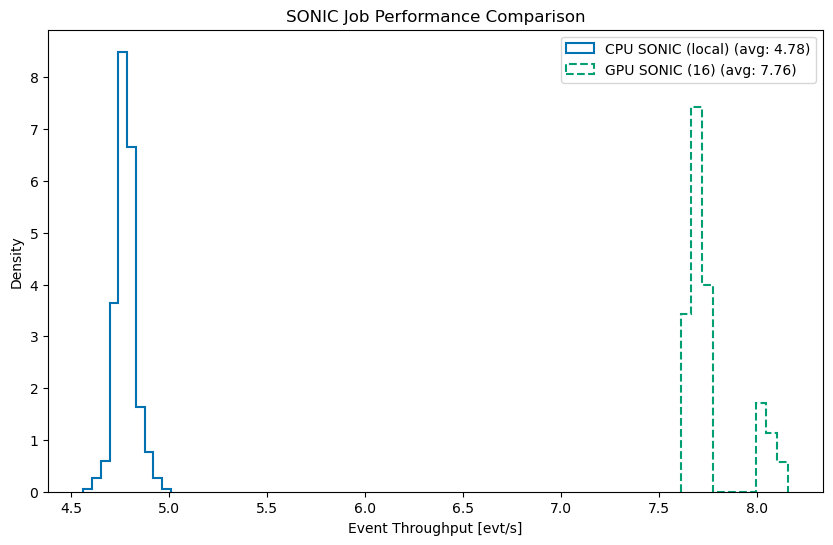

In [10]:
def plot_comparison_histogram(datasets_dict, title, dataset_names=None):
    """Create a comparison histogram for multiple datasets."""
    if not datasets_dict:
        print("No datasets available for comparison")
        return
    
    # Filter datasets if specific names provided
    if dataset_names:
        datasets_dict = {name: df for name, df in datasets_dict.items() if name in dataset_names}
    
    # Filter out empty datasets
    valid_datasets = {name: df for name, df in datasets_dict.items() 
                     if not df.empty and 'evt/s' in df.columns}
    
    if not valid_datasets:
        print("No valid datasets with throughput data for comparison")
        return
    
    plt.figure(figsize=PLOT_CONFIG['figsize'])
    
    for name, df in valid_datasets.items():
        # Get style for this dataset
        style = STYLE_CONFIG.get(name, {'color': f'C{len(plt.gca().lines)}', 'linestyle': '-', 'label': name})
        
        plt.hist(df['evt/s'],
                density=PLOT_CONFIG['density'],
                bins=PLOT_CONFIG['bins'],
                histtype=PLOT_CONFIG['histtype'],
                color=style['color'],
                linestyle=style['linestyle'],
                linewidth=PLOT_CONFIG['linewidth'],
                label=f"{style['label']} (avg: {df['evt/s'].mean():.2f})")
    
    plt.title(title)
    plt.xlabel('Event Throughput [evt/s]')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Plot all available datasets
plot_comparison_histogram(
    datasets,
    'SONIC Job Performance Comparison'
)